# turbulent air-sea fluxes bar charts

In [1]:
import intake
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt 
import calendar
import cmocean as cmo
from dask.distributed import Client

from os import environ
environ["PYTHONWARNINGS"] = "ignore"

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


## Some (very specific) functions

In [2]:
def compute_climatologies(experiments, var_names, catalog, frequency, 
                          start_time, end_time, region_lat, region_lon):
    """
    Compute monthly climatologies for one or more variables across multiple experiments.

    Parameters
    ----------
    experiments : dict
        Mapping of resolution tags (e.g., '010', '025') to experiment names.
    var_names : str | list | dict
        Variable name(s) for each experiment:
        - Single string if all experiments use the same name.
        - List of names (must match order/length of experiments).
        - Dict keyed by resolution (e.g., {'010': 'sst', '025': 'temp', ...}).
    catalog : intake catalog
        Intake catalog containing the experiment datasets.
    frequency : str
        Frequency string used in the catalog search.
    start_time, end_time : str
        Time range for selection (e.g., '2000-01-01', '2010-12-31').
    region_lat, region_lon : list or tuple
        Latitude and longitude bounds [min, max] for selection.

    Returns
    -------
    dict
        Dictionary of xarray Datasets containing monthly climatologies for each resolution.
    """

    var_climatologies = {}

    # Convert list to dict if needed
    if isinstance(var_names, list):
        var_names = dict(zip(experiments.keys(), var_names))
    elif isinstance(var_names, str):
        var_names = {res: var_names for res in experiments.keys()}

    for res, expt_name in experiments.items():
        var = var_names[res]

        # Load dataset
        var_ds = catalog[expt_name].search(variable=var, frequency=frequency).to_dask()

        # Select time / lat / lon range
        var_ds = var_ds.sel(time=slice(start_time, end_time))
        var_ds = var_ds.sel(yt_ocean=slice(region_lat[0], region_lat[1]))
        var_ds = var_ds.sel(xt_ocean=slice(region_lon[0], region_lon[1]))

        # --- Compute climatology (monthly mean) ---
        var_clim = var_ds.groupby("time.month").mean("time")

        # Store processed climatology
        var_climatologies[res] = var_clim

    return var_climatologies

## Main code

In [3]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43153,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38157,Total threads: 1
Dashboard: /proxy/35705/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:42005,


In [4]:
catalog = intake.cat.access_nri
#variables = catalog.search(name='025deg_jra55_iaf_omip2_cycle6', frequency = '1mon').unique().variable
#print(variables)

In [61]:
# --- common parameters
frequency = '1mon'
start_time = "1999-01-01"
end_time = "2018-12-31"

region_lat   = np.array([-56,-29])                    # yt_ocean,N
region_lon   = np.array([129,161]) 
region_lon   = region_lon - 360  

inset_lat   = np.array([-47.5,-46])                    # yt_ocean,N
inset_lon   = np.array([141.2,142.7]) 
inset_lon   = inset_lon - 360  

experiments = {
    "0.1": "01deg_jra55v140_iaf_cycle4",
    "0.25": "025deg_jra55_iaf_omip2_cycle6",
    "1.0": "1deg_jra55_iaf_omip2_cycle6",
}

In [51]:
# --- common plot features
titles = [r"ACCESS-OM2 $1.0^\circ$", r"ACCESS-OM2 $0.25^\circ$", r"ACCESS-OM2 $0.1^\circ$"]

In [52]:
# --- load / average data to produce monthly climatology
var_names = "evap_heat"
latent_climatologies = compute_climatologies(
    experiments = experiments,
    var_names = var_names,
    catalog = catalog,
    frequency = frequency,
    start_time = start_time,
    end_time = end_time,
    region_lat = inset_lat,
    region_lon = inset_lon,
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [53]:
# --- load / average data to produce monthly climatology
var_names = "sens_heat"
sensible_climatologies = compute_climatologies(
    experiments = experiments,
    var_names = var_names,
    catalog = catalog,
    frequency = frequency,
    start_time = start_time,
    end_time = end_time,
    region_lat = inset_lat,
    region_lon = inset_lon,
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [54]:
# --- load / average data to produce monthly climatology
var_names = "net_sfc_heating"
net_climatologies = compute_climatologies(
    experiments = experiments,
    var_names = var_names,
    catalog = catalog,
    frequency = frequency,
    start_time = start_time,
    end_time = end_time,
    region_lat = inset_lat,
    region_lon = inset_lon,
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [55]:
# --- load / average data to produce monthly climatology
var_names = "swflx"
sw_climatologies = compute_climatologies(
    experiments = experiments,
    var_names = var_names,
    catalog = catalog,
    frequency = frequency,
    start_time = start_time,
    end_time = end_time,
    region_lat = inset_lat,
    region_lon = inset_lon,
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [56]:
# --- load / average data to produce monthly climatology
var_names = "lw_heat"
lw_climatologies = compute_climatologies(
    experiments = experiments,
    var_names = var_names,
    catalog = catalog,
    frequency = frequency,
    start_time = start_time,
    end_time = end_time,
    region_lat = inset_lat,
    region_lon = inset_lon,
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [59]:
winter_sw = [sw_climatologies['1.0']['swflx'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             sw_climatologies['0.25']['swflx'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             sw_climatologies['0.1']['swflx'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             51.2]

winter_lw = [lw_climatologies['1.0']['lw_heat'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             lw_climatologies['0.25']['lw_heat'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             lw_climatologies['0.1']['lw_heat'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
              -44.5]

winter_net = [net_climatologies['1.0']['net_sfc_heating'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             net_climatologies['0.25']['net_sfc_heating'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             net_climatologies['0.1']['net_sfc_heating'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
              -83.5]

winter_sensible = [sensible_climatologies['1.0']['sens_heat'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             sensible_climatologies['0.25']['sens_heat'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             sensible_climatologies['0.1']['sens_heat'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             -17.2]

winter_latent = [latent_climatologies['1.0']['evap_heat'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             latent_climatologies['0.25']['evap_heat'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             latent_climatologies['0.1']['evap_heat'].sel(month = slice(6,8)).mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             -73.1]


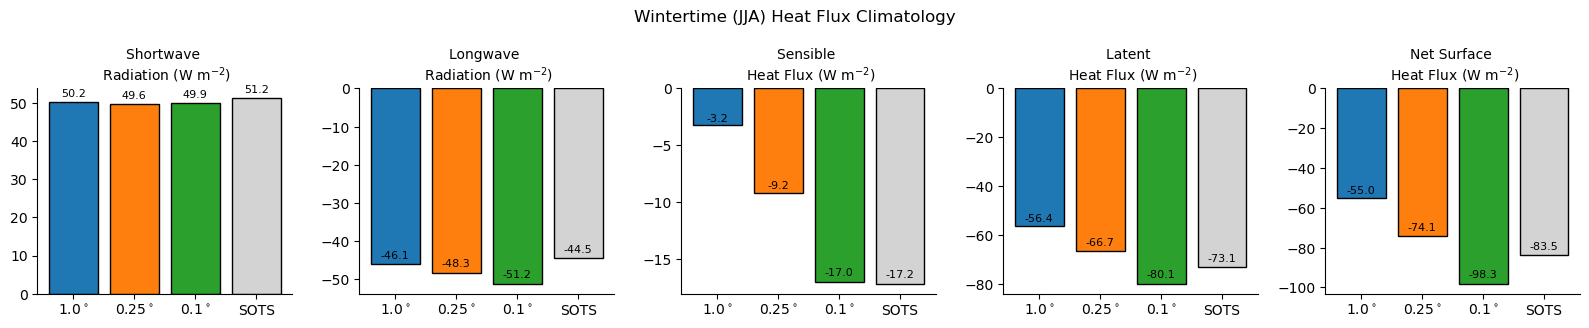

In [60]:
labels = ['1.0$^\circ$', '0.25$^\circ$', '0.1$^\circ$', 'SOTS']

# Group the data + labels
data_list = [
    (winter_sw,        'Shortwave \n Radiation (W m$^{-2}$)'),
    (winter_lw,        'Longwave \n Radiation (W m$^{-2}$)'),
    (winter_sensible,  'Sensible \n Heat Flux (W m$^{-2}$)'),
    (winter_latent,    'Latent \n Heat Flux (W m$^{-2}$)'),
    (winter_net,       'Net Surface \n Heat Flux (W m$^{-2}$)'),

]

colors = ['tab:blue', 'tab:orange', 'tab:green', 'lightgray']   
fig, axes = plt.subplots(
    nrows=1, ncols=5, figsize=(16, 3.3), sharey=False
)

for ax, (dataset, ylabel) in zip(axes, data_list):
    # Bar plot
    ax.bar(labels, dataset, color=colors, edgecolor = 'k')

    # Add numeric labels above bars
    for i, val in enumerate(dataset):
        ax.text(i, val + 0.02 * abs(val), f"{val:.1f}",
                ha='center', va='bottom', fontsize=8)

    # Labels + formatting
    ax.set_title(ylabel, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=0)

# Shared X label centered under the whole figure
#fig.text(0.5, -0.02, 'Resolution', ha='center', fontsize=12)

plt.suptitle('Wintertime (JJA) Heat Flux Climatology')
plt.tight_layout()
plt.savefig("heat-fluxes-wintertime-bar-plots.png", dpi=300, bbox_inches="tight")

plt.show()

In [45]:
annual_sw = [sw_climatologies['1.0']['swflx'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             sw_climatologies['0.25']['swflx'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             sw_climatologies['0.1']['swflx'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
              ]

annual_lw = [lw_climatologies['1.0']['lw_heat'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             lw_climatologies['0.25']['lw_heat'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             lw_climatologies['0.1']['lw_heat'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
              ]

annual_net = [net_climatologies['1.0']['net_sfc_heating'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             net_climatologies['0.25']['net_sfc_heating'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             net_climatologies['0.1']['net_sfc_heating'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
              ]

annual_sensible = [sensible_climatologies['1.0']['sens_heat'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             sensible_climatologies['0.25']['sens_heat'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             sensible_climatologies['0.1']['sens_heat'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
              ]

annual_latent = [latent_climatologies['1.0']['evap_heat'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             latent_climatologies['0.25']['evap_heat'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
             latent_climatologies['0.1']['evap_heat'].mean(dim = ['yt_ocean', 'xt_ocean', 'month']).compute(),
                ]


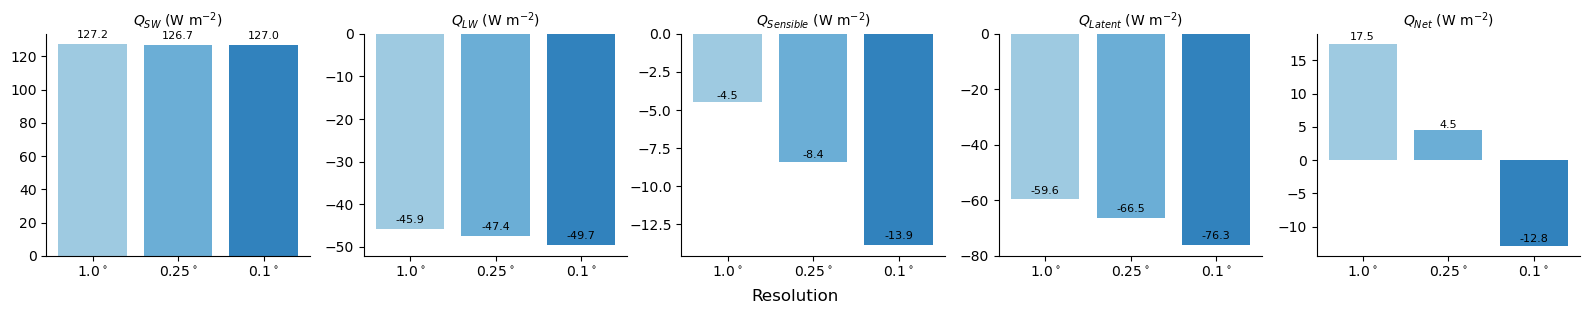

In [46]:
labels = ['1.0$^\circ$', '0.25$^\circ$', '0.1$^\circ$']

# Group the data + labels
data_list = [
    (annual_sw,        '$Q_{SW}$ (W m$^{-2}$)'),
    (annual_lw,        '$Q_{LW}$ (W m$^{-2}$)'),
    (annual_sensible,  '$Q_{Sensible}$ (W m$^{-2}$)'),
    (annual_latent,    '$Q_{Latent}$ (W m$^{-2}$)'),
    (annual_net,       '$Q_{Net}$ (W m$^{-2}$)'),

]

colors = ['#9ecae1', '#6baed6', '#3182bd']   
fig, axes = plt.subplots(
    nrows=1, ncols=5, figsize=(16, 3), sharey=False
)

for ax, (dataset, ylabel) in zip(axes, data_list):
    # Bar plot
    ax.bar(labels, dataset, color=colors)

    # Add numeric labels above bars
    for i, val in enumerate(dataset):
        ax.text(i, val + 0.02 * abs(val), f"{val:.1f}",
                ha='center', va='bottom', fontsize=8)

    # Labels + formatting
    ax.set_title(ylabel, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=0)

# Shared X label centered under the whole figure
fig.text(0.5, -0.02, 'Resolution', ha='center', fontsize=12)

plt.tight_layout()
plt.show()